In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [58]:
data = pd.read_csv("spotify_songs.csv")
print(f"The dataset has {data.shape[0]} rows and {data.shape[1]} columns")
data.dtypes

The dataset has 32833 rows and 23 columns


track_id                     object
track_name                   object
track_artist                 object
track_popularity              int64
track_album_id               object
track_album_name             object
track_album_release_date     object
playlist_name                object
playlist_id                  object
playlist_genre               object
playlist_subgenre            object
danceability                float64
energy                      float64
key                           int64
loudness                    float64
mode                          int64
speechiness                 float64
acousticness                float64
instrumentalness            float64
liveness                    float64
valence                     float64
tempo                       float64
duration_ms                   int64
dtype: object

In [59]:
data.isna().sum()

track_id                    0
track_name                  5
track_artist                5
track_popularity            0
track_album_id              0
track_album_name            5
track_album_release_date    0
playlist_name               0
playlist_id                 0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64

In [60]:
data.columns

Index(['track_id', 'track_name', 'track_artist', 'track_popularity',
       'track_album_id', 'track_album_name', 'track_album_release_date',
       'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms'],
      dtype='object')

In [61]:
data.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


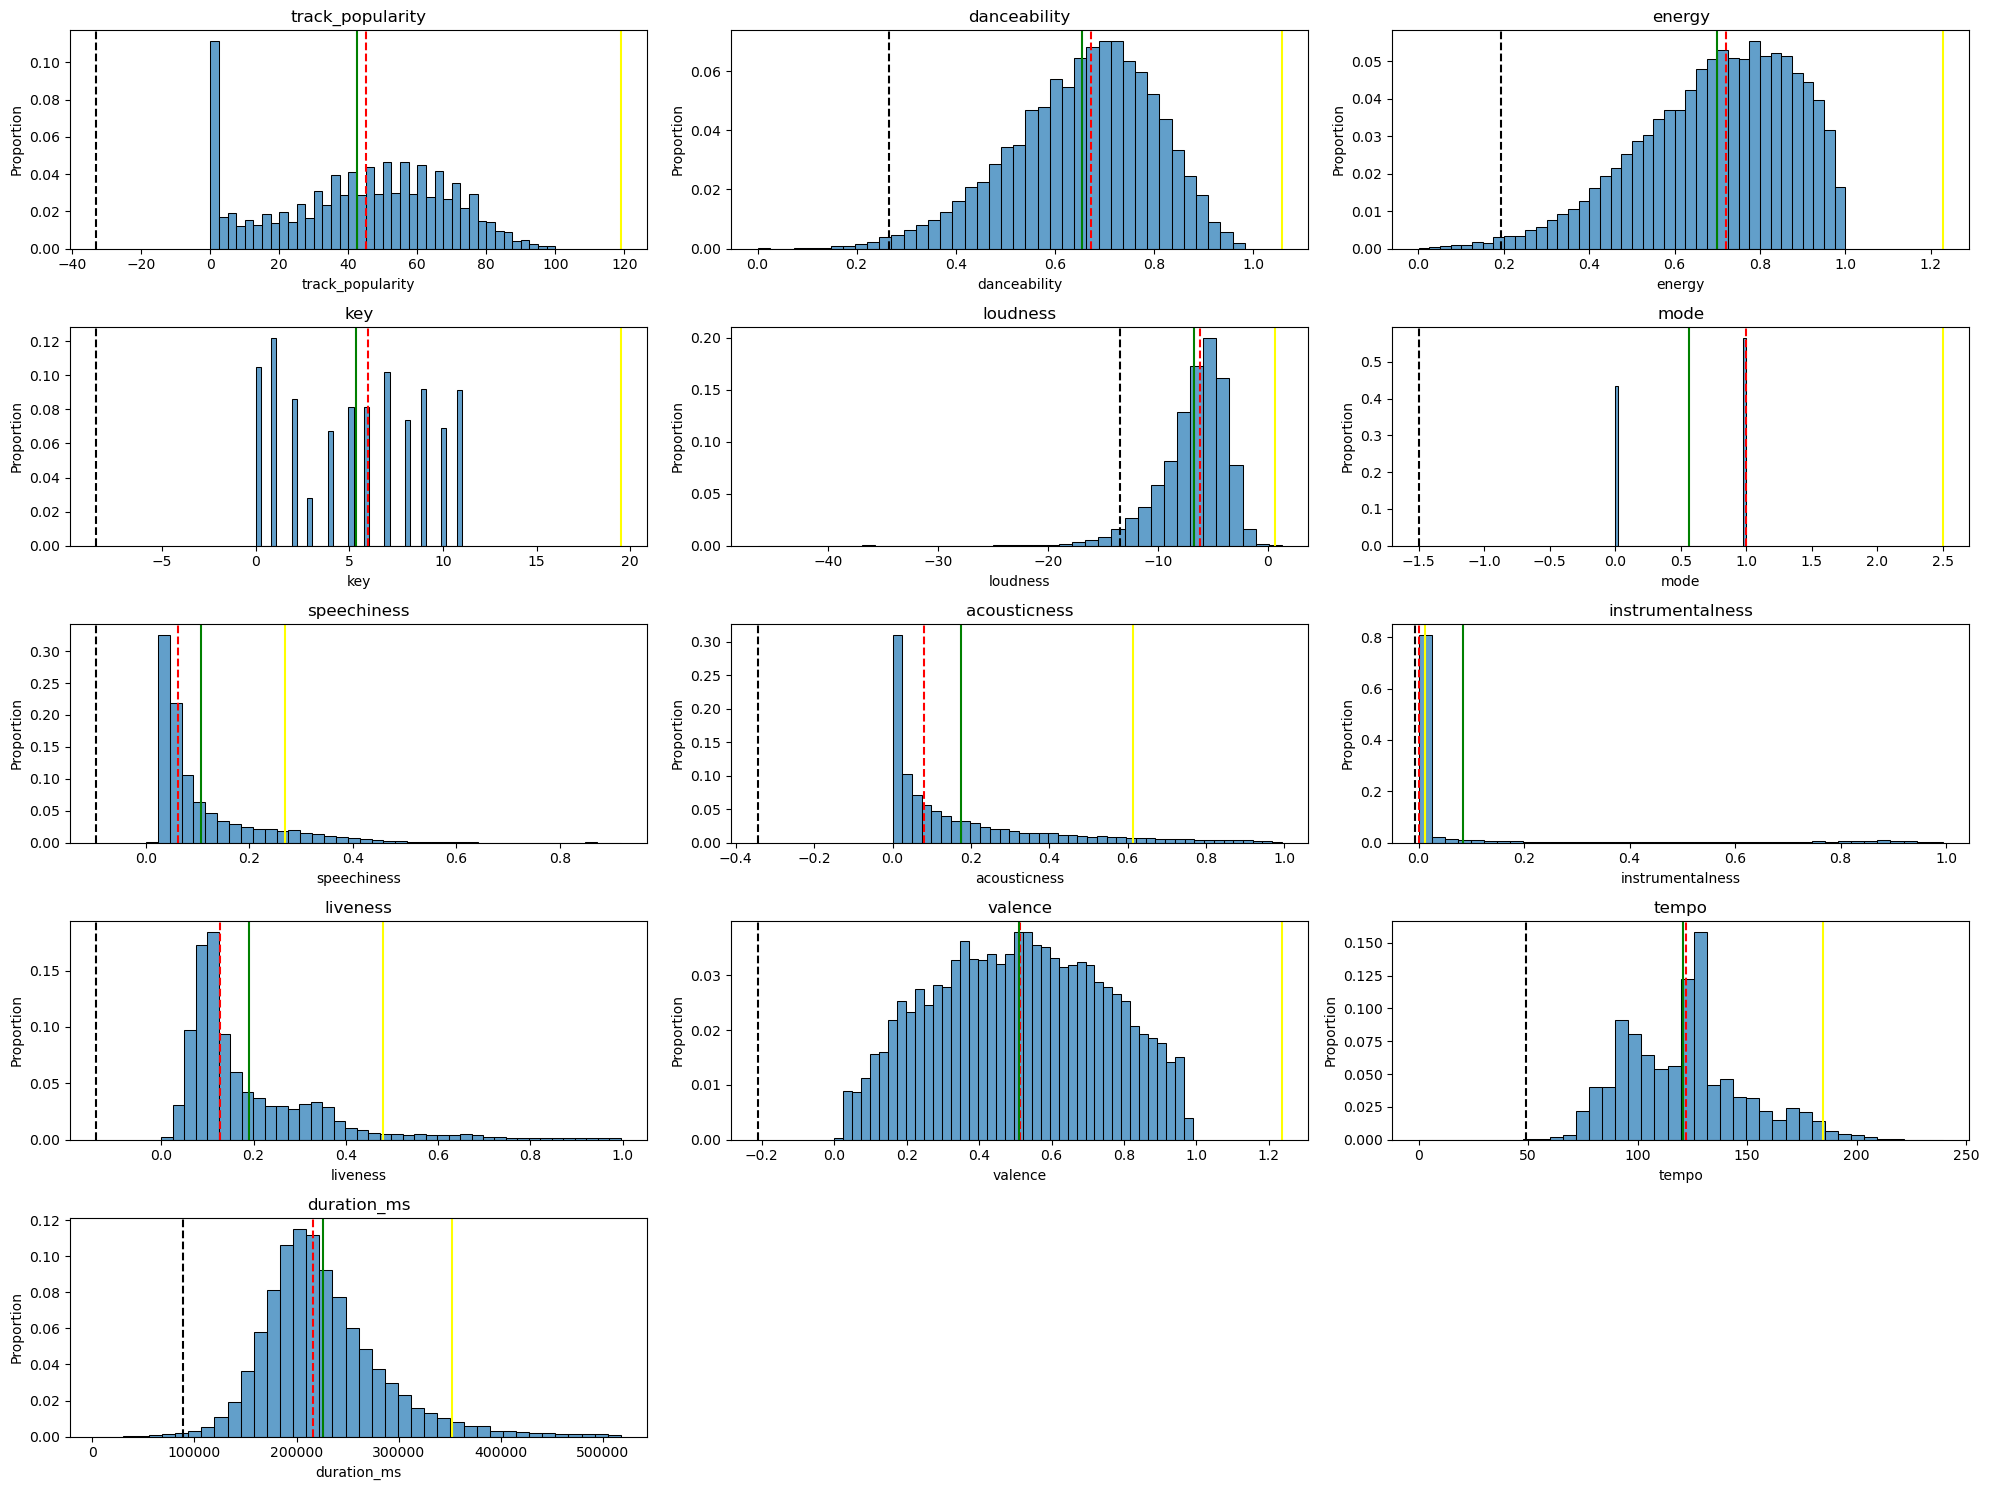

In [62]:

numeric_cols = data.select_dtypes(include='number').columns


plt.figure(figsize=(20, 15))
for i, col in enumerate(numeric_cols, 1):
    median= data[col].median()
    mean=data[col].mean()

    feature_q1 = data[col].quantile(0.25)
    feature_q3 = data[col].quantile(0.75)
    feature_iqr = feature_q3 - feature_q1
    l_bound = feature_q1 - 1.5* feature_iqr
    u_bound = feature_q3 + 1.5*feature_iqr

    plt.subplot(len(numeric_cols)//3 + 1, 3, i)
    sns.histplot(data=data,x=col, bins=40, alpha=0.7,stat="proportion")
    plt.axvline(median, color='red', linestyle='--', label='Median')
    plt.axvline(mean, color='green', linestyle='-', label='Mean')
    plt.axvline(l_bound, color='black', linestyle='--', label='Lower Bound')
    plt.axvline(u_bound, color='yellow', linestyle='-', label='Upper Bound')


    plt.title(col)
plt.tight_layout()


plt.show()

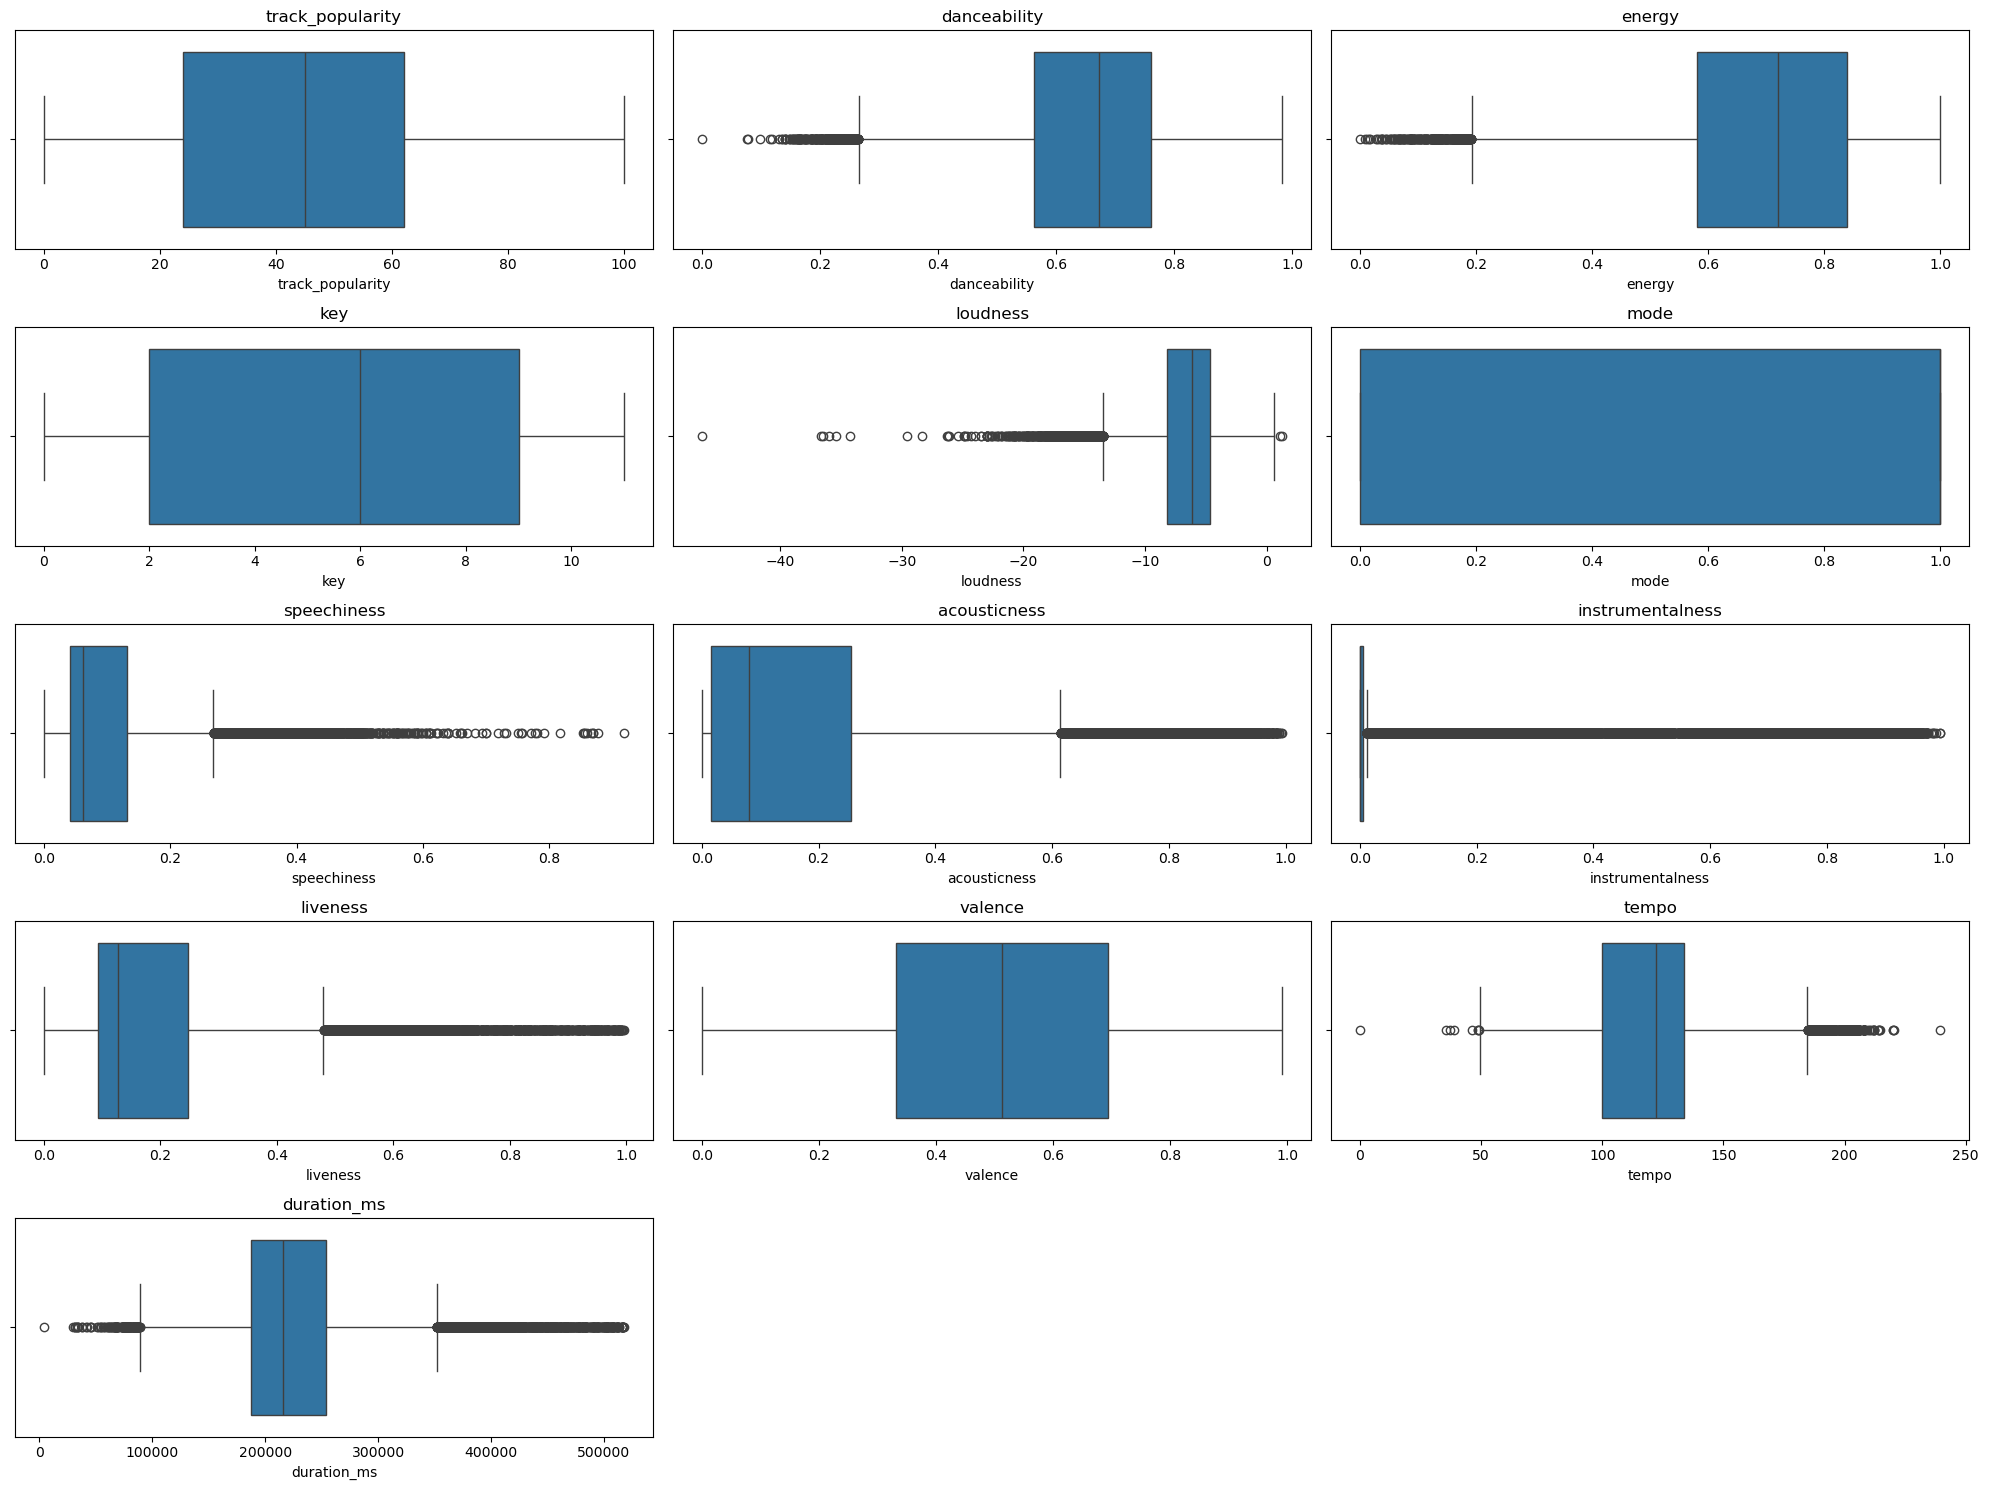

In [63]:

numeric_cols = data.select_dtypes(include='number').columns

plt.figure(figsize=(20, 15))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols)//3 + 1, 3, i)
    sns.boxplot(data=data, x=col,whis=1.5)
    plt.title(col)
plt.tight_layout()
plt.show()

In [64]:
data = data.dropna(subset=['track_name'])


In [65]:
data.sort_values(by=['playlist_genre', 'playlist_subgenre'], inplace=True)
data.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
28301,37FfCz1YODL6NAuWfxUzJh,Left Right,Hardwell,58,3192TqWaoGyc53bEHlcl45,Left Right,2019-10-18,Big Room EDM,3S03NWbWkrR1e7DPH9rf9Z,edm,...,10,-3.768,0,0.0666,0.000373,0.353000,0.2850,0.192,128.005,155827
28302,6RnkFd8Fqqgk1Uni8RgqCQ,Like I Do,David Guetta,72,5oU1ROIHS6IOWnb87GWhqU,Like I Do,2018-02-22,Big Room EDM,3S03NWbWkrR1e7DPH9rf9Z,edm,...,0,-3.719,0,0.0377,0.006640,0.014500,0.3700,0.150,127.978,202500
28303,1dVbC0XoM4VxpDkrv1tcjf,Catching Fire,Ryos,44,4HMuUkqnzXtG4c9CVe0WiR,Catching Fire,2020-01-10,Big Room EDM,3S03NWbWkrR1e7DPH9rf9Z,edm,...,3,-4.877,0,0.1550,0.077600,0.000002,0.1750,0.343,128.096,204375
28304,1RES1p3VXofj02iOJ65ZaA,Not Alone - REGGIO Remix,Sick Individuals,49,432U2hmbbsuVY42KUqIJ3P,Not Alone (REGGIO Remix),2020-01-08,Big Room EDM,3S03NWbWkrR1e7DPH9rf9Z,edm,...,1,-4.552,1,0.0372,0.000287,0.105000,0.3220,0.294,128.016,175312
28305,29C3wkt3HoxHtEalb0mUWP,I'm In Love,NDR8,34,4FeSeO5vSj5W7dFajS0osc,I'm In Love,2020-01-10,Big Room EDM,3S03NWbWkrR1e7DPH9rf9Z,edm,...,7,-2.741,0,0.0841,0.002160,0.642000,0.0788,0.450,126.048,140615


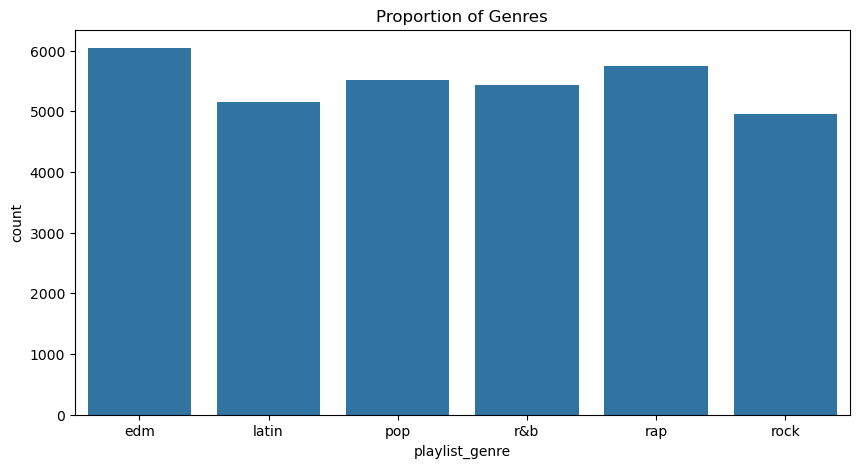

In [66]:

plt.figure(figsize=(10, 5))
sns.countplot(x='playlist_genre',data=data,)
plt.title("Proportion of Genres")
plt.show()

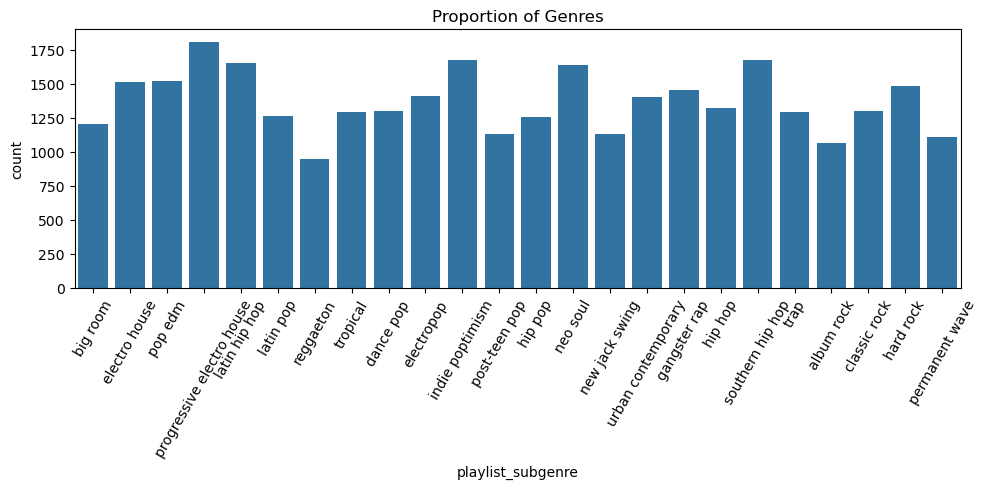

In [73]:

plt.figure(figsize=(10, 5))
sns.countplot(x='playlist_subgenre',data=data,)
plt.title("Proportion of Genres")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

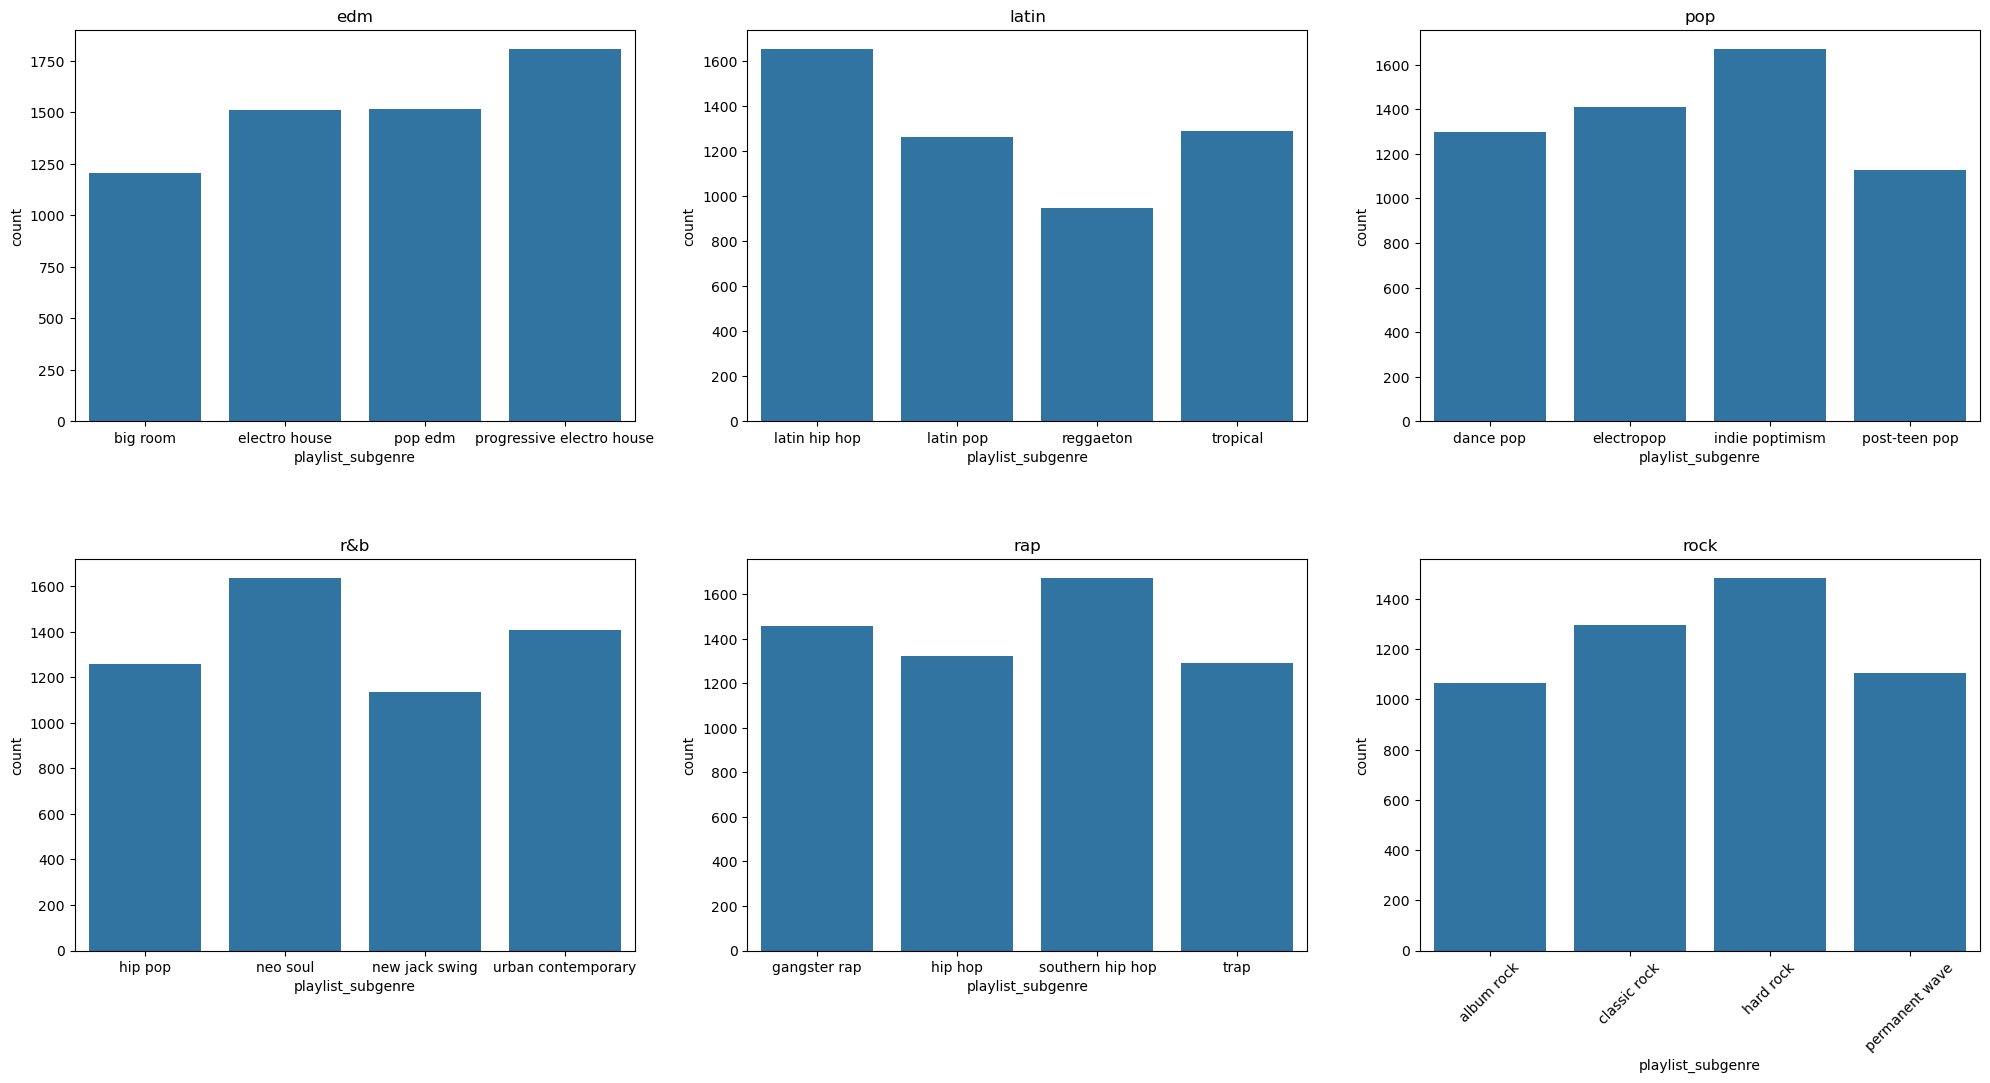

In [70]:
genre= data['playlist_genre'].unique()

plt.figure(figsize=(20, 15))
for i, col in enumerate(genre, 1):
    plt.subplot(len(genre)//3 + 1, 3, i)
    subgenre=data[data['playlist_genre']== col]
    sns.countplot(data=subgenre, x='playlist_subgenre',)
    plt.title(col)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()